# Sales Forecast Exploration

This notebook reads daily sales history from PostgreSQL, plots actuals, computes a 7-day rolling average, and builds a simple 2nd-degree polynomial forecast for the next 30 days.

In [1]:
import os
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import psycopg
load_dotenv('../.env')
conn = psycopg.connect(
    host=os.getenv('DB_HOST', 'localhost'),    
    port=os.getenv('DB_PORT', '5432'),
    dbname=os.getenv('DB_NAME', 'lambda_lab'),
    user=os.getenv('DB_USER', 'lambda_lab'),
    password=os.getenv('DB_PASSWORD', 'lambda_lab')
)

In [2]:
query = '''
SELECT sales_date, orders_count, units_sold, gross_sales, avg_order_value
FROM daily_sales_summary
ORDER BY sales_date
'''
df = pd.read_sql(query, conn)
df['sales_date'] = pd.to_datetime(df['sales_date'])
df['day_index'] = np.arange(len(df))
df['rolling_avg_7d'] = df['gross_sales'].rolling(window=7, min_periods=1).mean()
df.head()

/tmp/ipykernel_20178/3725859817.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,sales_date,orders_count,units_sold,gross_sales,avg_order_value,day_index,rolling_avg_7d
0,2025-09-01,16,24,5231.47,326.97,0,5231.470000
1,2025-09-02,18,32,5375.50,298.64,1,5303.485000
2,2025-09-03,21,33,4400.40,209.54,2,5002.456667
3,2025-09-04,24,39,7817.49,325.73,3,5706.215000
4,2025-09-05,22,38,6643.25,301.97,4,5893.622000


In [3]:
coeffs = np.polyfit(df['day_index'], df['gross_sales'], deg=2)
poly = np.poly1d(coeffs)
df['poly_fit'] = poly(df['day_index'])

forecast_days = 30
future_index = np.arange(len(df), len(df) + forecast_days)
future_dates = pd.date_range(df['sales_date'].max() + timedelta(days=1), periods=forecast_days, freq='D')
future_forecast = poly(future_index)
future_forecast = np.maximum(future_forecast, 0)

forecast_df = pd.DataFrame({
    'sales_date': future_dates,
    'forecast_gross_sales': future_forecast
})

forecast_df.head()

,sales_date,forecast_gross_sales
0,2026-02-28,9633.054018
1,2026-03-01,9664.471980
2,2026-03-02,9695.927817
3,2026-03-03,9727.421530
4,2026-03-04,9758.953117


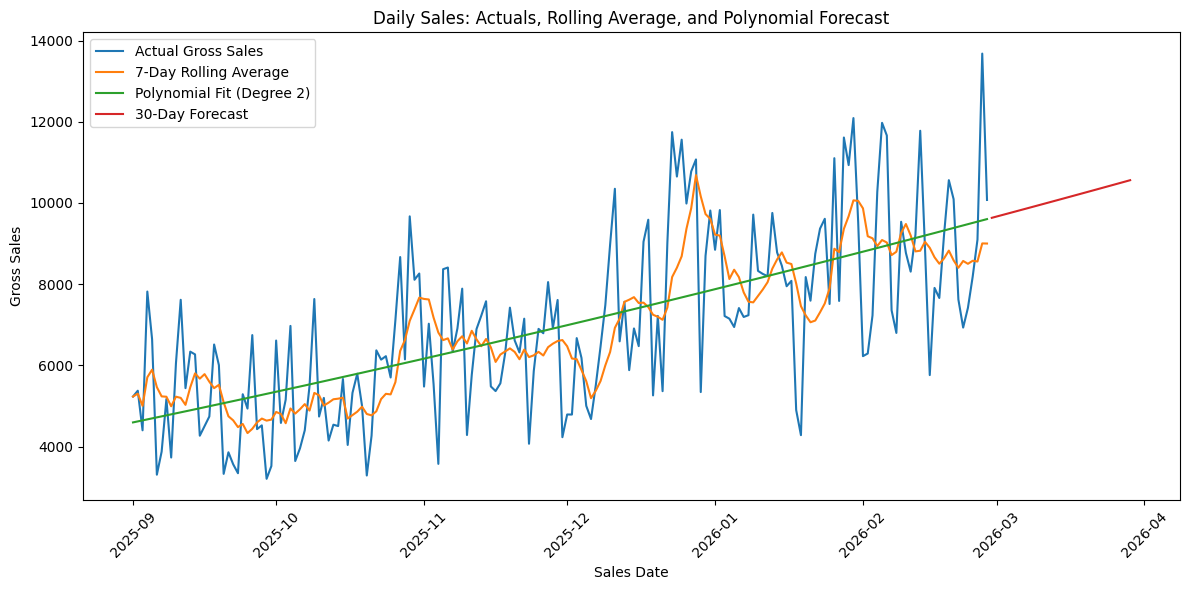

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df['sales_date'], df['gross_sales'], label='Actual Gross Sales')
plt.plot(df['sales_date'], df['rolling_avg_7d'], label='7-Day Rolling Average')
plt.plot(df['sales_date'], df['poly_fit'], label='Polynomial Fit (Degree 2)')
plt.plot(forecast_df['sales_date'], forecast_df['forecast_gross_sales'], label='30-Day Forecast')
plt.title('Daily Sales: Actuals, Rolling Average, and Polynomial Forecast')
plt.xlabel('Sales Date')
plt.ylabel('Gross Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
forecast_df.round(2).tail(10)

,sales_date,forecast_gross_sales
20,2026-03-20,10268.61
21,2026-03-21,10300.78
22,2026-03-22,10333.00
23,2026-03-23,10365.25
24,2026-03-24,10397.54
25,2026-03-25,10429.87
26,2026-03-26,10462.23
27,2026-03-27,10494.63
28,2026-03-28,10527.07
29,2026-03-29,10559.55
